# Comparaison de lettres manuscrites — 1007 vs 1054

Ce notebook compare, lettre par lettre, des images 32×32 issues de deux manuscrits (**1007** et **1054**), pour les mêmes mots.

Étapes : chargement → appariement mot/lettre → **centrage** des lettres dans leur cadre → construction d'une **matrice de features** → **similarité cosinus** calculée de façon vectorisée → tableau visuel :

`mot | lettre | image 1007 | image 1054 | score de similarité`

**Format attendu des noms de fichiers** : `MANUSCRIT_MOT_LETTRE_thresh_32x32.png`
(ex : `1007_description_e_thresh_32x32.png`, `1054_description_e_thresh_32x32.png`)


## 1. Import des librairies

In [3]:
import os
import re
import zipfile
import base64
from io import BytesIO
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage
import matplotlib.pyplot as plt
from IPython.display import display, HTML


## 2. Chargement des images

Exécutez la cellule ci-dessous : elle vous propose d'uploader **soit une archive `.zip`** contenant les images, **soit les images individuellement** (sélection multiple).

⚠️ Important : que ce soit en zip ou en fichiers séparés, les images doivent **garder leur nom d'origine** (`MANUSCRIT_MOT_LETTRE_thresh_32x32.png`) — c'est ce nom qui permet à la section 3 de retrouver le manuscrit, le mot et la lettre, et donc de faire l'appariement.

In [4]:
DATA_DIR = "/content/lettres"

def _find_image_folder(root):
    """Cherche le dossier qui contient réellement les .png (gère un éventuel sous-dossier imbriqué)."""
    for dirpath, dirnames, filenames in os.walk(root):
        if any(f.lower().endswith(".png") for f in filenames):
            return dirpath
    return root

if not os.path.isdir(DATA_DIR) or not any(
    f.lower().endswith(".png") for f in os.listdir(_find_image_folder(DATA_DIR)) if os.path.isdir(DATA_DIR)
):
    try:
        from google.colab import files
        os.makedirs(DATA_DIR, exist_ok=True)
        print("📤 Choisissez soit une archive .zip, soit vos images individuellement (sélection multiple)")
        uploaded = files.upload()

        zip_names = [n for n in uploaded if n.lower().endswith(".zip")]
        if zip_names:
            # Cas 1 : une archive zip -> on l'extrait telle quelle (les noms de fichiers internes sont préservés)
            with zipfile.ZipFile(BytesIO(uploaded[zip_names[0]]), "r") as z:
                z.extractall(DATA_DIR)
            print("Extraction terminée dans", DATA_DIR)
        else:
            # Cas 2 : images individuelles -> on les écrit sur disque en conservant leur nom d'origine
            for name, content in uploaded.items():
                if name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
                    with open(os.path.join(DATA_DIR, name), "wb") as f:
                        f.write(content)
            print(f"{len(uploaded)} fichiers écrits dans", DATA_DIR)
    except ImportError:
        raise RuntimeError(
            f"Aucune image trouvée dans {DATA_DIR} et google.colab indisponible. "
            "Placez vos images dans ce dossier ou exécutez ce notebook sur Google Colab."
        )

IMAGE_DIR = _find_image_folder(DATA_DIR)
png_files = [f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(".png")]
print(f"{len(png_files)} images trouvées dans : {IMAGE_DIR}")


📤 Choisissez soit une archive .zip, soit vos images individuellement (sélection multiple)


Saving All datz.zip to All datz.zip
Extraction terminée dans /content/lettres
128 images trouvées dans : /content/lettres/All datz


## 3. Analyse des noms de fichiers et appariement des lettres

Chaque image est identifiée par : manuscrit (1007 / 1054), mot, lettre.

On apparie automatiquement, pour un même mot, la lettre du manuscrit 1007 avec la même lettre du manuscrit 1054.
Un mécanisme de secours gère les petites incohérences de nommage (ex: `s` vs `s1` pour une même occurrence de lettre), et affiche un avertissement dans ce cas pour que vous puissiez vérifier.

In [5]:
FILENAME_PATTERN = re.compile(r'^(\d{4})_([A-Za-z]+)_([A-Za-z0-9]+)_thresh_32x32\.png$')

data = defaultdict(lambda: defaultdict(dict))  # data[manuscrit][mot][lettre] = chemin_fichier
unparsed = []

for fname in png_files:
    m = FILENAME_PATTERN.match(fname)
    if not m:
        unparsed.append(fname)
        continue
    manuscrit, mot, lettre = m.groups()
    data[manuscrit][mot][lettre] = os.path.join(IMAGE_DIR, fname)

if unparsed:
    print("Fichiers ignorés (nom non reconnu) :")
    for f in unparsed:
        print("  -", f)

MANUSCRIT_A = "1007"
MANUSCRIT_B = "1054"

def _split_label(label):
    """Sépare une étiquette de lettre en (base alphabétique, indice numérique)."""
    m = re.match(r'^([A-Za-z]+)(\d*)$', label)
    base, suf = m.groups()
    return base, (int(suf) if suf else 0)

pairs = []       # liste de dicts : mot, lettre, chemin_1007, chemin_1054
warnings_list = []

mots = sorted(set(data[MANUSCRIT_A].keys()) | set(data[MANUSCRIT_B].keys()))

for mot in mots:
    lettres_a = data[MANUSCRIT_A].get(mot, {})
    lettres_b = data[MANUSCRIT_B].get(mot, {})
    keys_a, keys_b = set(lettres_a), set(lettres_b)

    # 1) correspondance exacte
    for lettre in sorted(keys_a & keys_b):
        pairs.append({"mot": mot, "lettre": lettre,
                       "chemin_1007": lettres_a[lettre], "chemin_1054": lettres_b[lettre]})

    # 2) correspondance approchée pour le reste (ex: s <-> s1)
    reste_a, reste_b = keys_a - keys_b, keys_b - keys_a
    if reste_a or reste_b:
        groupes_a, groupes_b = defaultdict(list), defaultdict(list)
        for k in reste_a:
            base, n = _split_label(k); groupes_a[base].append((n, k))
        for k in reste_b:
            base, n = _split_label(k); groupes_b[base].append((n, k))

        for base in sorted(set(groupes_a) | set(groupes_b)):
            ga, gb = sorted(groupes_a.get(base, [])), sorted(groupes_b.get(base, []))
            n_pairs = min(len(ga), len(gb))
            for i in range(n_pairs):
                k_a, k_b = ga[i][1], gb[i][1]
                label = k_a if k_a == k_b else f"{k_a}/{k_b}"
                pairs.append({"mot": mot, "lettre": label,
                               "chemin_1007": lettres_a[k_a], "chemin_1054": lettres_b[k_b]})
                warnings_list.append(f"Appariement approché : {mot} -> '{k_a}' (1007) <-> '{k_b}' (1054)")
            for extra in ga[n_pairs:]:
                warnings_list.append(f"NON APPARIÉ : {mot}_{extra[1]} (1007) — aucune lettre correspondante en 1054")
            for extra in gb[n_pairs:]:
                warnings_list.append(f"NON APPARIÉ : {mot}_{extra[1]} (1054) — aucune lettre correspondante en 1007")

print(f"{len(pairs)} paires de lettres appariées.")
if warnings_list:
    print("\nAvertissements :")
    for w in warnings_list:
        print("  -", w)


64 paires de lettres appariées.

Avertissements :
  - Appariement approché : troisieme -> 's' (1007) <-> 's1' (1054)


## 4. Centrage des lettres

Deux lettres identiques peuvent être décalées différemment dans leur cadre 32×32 (marge à gauche/droite/haut/bas différente selon le manuscrit). Or la similarité cosinus, calculée pixel à pixel, est sensible à ce décalage : un simple décalage de quelques pixels peut faire chuter le score alors que la forme de la lettre est identique.

On centre donc chaque lettre sur son **centre de masse** (le "poids" de chaque pixel étant son intensité d'encre) avant de comparer les images. Le fond est d'abord inversé (fond → 0, trait → valeurs fortes) pour que le calcul du centre de masse ne soit pas parasité par le fond blanc uniforme, puis l'image est translatée pour amener ce centre de masse au centre exact du cadre 32×32.

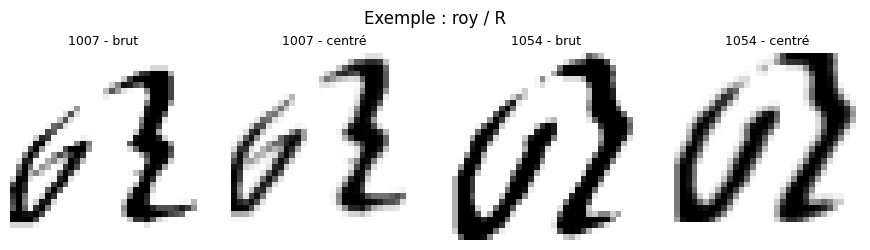

In [6]:
def charger_image_inversee(chemin):
    """Charge une image en niveaux de gris et inverse les intensités :
    fond blanc -> 0, trait de la lettre -> valeur forte."""
    arr = np.array(Image.open(chemin).convert("L"), dtype=np.float64)
    return 255.0 - arr

def centrer_lettre(arr_inverse, taille=32):
    """Translate l'image (déjà inversée) pour amener le centre de masse de l'encre
    au centre du cadre. Les zones qui apparaissent lors du décalage sont remplies de fond (0)."""
    total = arr_inverse.sum()
    if total == 0:
        return arr_inverse.copy()  # image vide : rien à centrer
    cy, cx = ndimage.center_of_mass(arr_inverse)
    cible = (taille - 1) / 2.0
    return ndimage.shift(arr_inverse, shift=(cible - cy, cible - cx), mode="constant", cval=0.0, order=1)

def pour_affichage(arr_inverse):
    """Reconvertit une image inversée (et éventuellement centrée) dans le sens normal pour l'affichage."""
    return np.clip(255.0 - arr_inverse, 0, 255)

# --- Démonstration visuelle avant / après centrage sur un exemple ---
exemple = next((p for p in pairs if p["mot"] == "roy" and p["lettre"] == "R"), pairs[0])

brut_1007 = charger_image_inversee(exemple["chemin_1007"])
brut_1054 = charger_image_inversee(exemple["chemin_1054"])
centre_1007 = centrer_lettre(brut_1007)
centre_1054 = centrer_lettre(brut_1054)

fig, axes = plt.subplots(1, 4, figsize=(9, 2.5))
for ax, arr, titre in zip(
    axes,
    [brut_1007, centre_1007, brut_1054, centre_1054],
    ["1007 - brut", "1007 - centré", "1054 - brut", "1054 - centré"],
):
    ax.imshow(pour_affichage(arr), cmap="gray", vmin=0, vmax=255)
    ax.set_title(titre, fontsize=9)
    ax.axis("off")
plt.suptitle(f"Exemple : {exemple['mot']} / {exemple['lettre']}")
plt.tight_layout()
plt.show()


## 5. Matrice de features et calcul vectorisé de la similarité cosinus

Plutôt que de comparer les images une par une dans une boucle, on construit directement une **matrice de features** (une ligne = une lettre, 1024 colonnes = les pixels aplatis) pour chaque manuscrit, dans le même ordre que les paires. La similarité cosinus de chaque paire est alors calculée en une seule opération vectorisée sur les deux matrices (normalisation des lignes puis produit scalaire ligne à ligne), plutôt qu'avec un appel par paire.

On calcule le score **avec centrage** (celui utilisé pour le tableau final) et, à titre de comparaison, le score **sans centrage**.

In [7]:
def construire_matrice(chemins, centrer=True):
    """Construit une matrice (n_images x 1024) à partir d'une liste de chemins d'images."""
    vecteurs = []
    for chemin in chemins:
        arr = charger_image_inversee(chemin)
        if centrer:
            arr = centrer_lettre(arr)
        vecteurs.append(arr.flatten())
    return np.stack(vecteurs)

def normaliser_lignes(matrice):
    normes = np.linalg.norm(matrice, axis=1, keepdims=True)
    normes[normes == 0] = 1.0  # évite une division par zéro pour une image totalement vide
    return matrice / normes

def similarite_cosinus_lignes(matrice_a, matrice_b):
    """Similarité cosinus calculée ligne à ligne (vectorisé) entre deux matrices alignées."""
    a_norm = normaliser_lignes(matrice_a)
    b_norm = normaliser_lignes(matrice_b)
    return np.sum(a_norm * b_norm, axis=1)

chemins_1007 = [p["chemin_1007"] for p in pairs]
chemins_1054 = [p["chemin_1054"] for p in pairs]

features_1007_brut   = construire_matrice(chemins_1007, centrer=False)
features_1054_brut   = construire_matrice(chemins_1054, centrer=False)
features_1007_centre = construire_matrice(chemins_1007, centrer=True)
features_1054_centre = construire_matrice(chemins_1054, centrer=True)

print("Matrice de features (centrée) :", features_1007_centre.shape, "-> (n_paires, 32*32)")

scores_bruts   = similarite_cosinus_lignes(features_1007_brut, features_1054_brut)
scores_centres = similarite_cosinus_lignes(features_1007_centre, features_1054_centre)

for i, p in enumerate(pairs):
    p["score"] = float(scores_centres[i])                # score principal, utilisé pour le tri/tableau/graphiques
    p["score_sans_centrage"] = float(scores_bruts[i])     # conservé à titre de comparaison

print(f"Similarité moyenne SANS centrage : {np.nanmean(scores_bruts):.4f}")
print(f"Similarité moyenne AVEC centrage : {np.nanmean(scores_centres):.4f}")


Matrice de features (centrée) : (64, 1024) -> (n_paires, 32*32)
Similarité moyenne SANS centrage : 0.6025
Similarité moyenne AVEC centrage : 0.6461


## 6. Tableau récapitulatif

Tableau demandé : `mot | lettre | image 1007 | image 1054 | score de similarité`, trié du score le plus faible au plus élevé (les paires les plus différentes en premier). Le score sans centrage est aussi affiché à titre de comparaison.

In [8]:
df = pd.DataFrame(pairs)[["mot", "lettre", "chemin_1007", "chemin_1054", "score", "score_sans_centrage"]]
df = df.sort_values("score", ascending=True).reset_index(drop=True)
df_affichage = df.rename(columns={
    "mot": "Mot", "lettre": "Lettre",
    "chemin_1007": "Fichier 1007", "chemin_1054": "Fichier 1054",
    "score": "Similarité cosinus (centrée)", "score_sans_centrage": "Similarité cosinus (brute)"
})
df_affichage


,Mot,Lettre,Fichier 1007,Fichier 1054,Similarité cosinus (centrée),Similarité cosinus (brute)
0,rejouissances,i,/content/lettres/All datz/1007_rejouissances_i...,/content/lettres/All datz/1054_rejouissances_i...,0.212758,0.089703
1,quatrieme,r,/content/lettres/All datz/1007_quatrieme_r_thr...,/content/lettres/All datz/1054_quatrieme_r_thr...,0.233444,0.640884
2,description,D,/content/lettres/All datz/1007_description_D_t...,/content/lettres/All datz/1054_description_D_t...,0.244068,0.265234
3,quatrieme,Q,/content/lettres/All datz/1007_quatrieme_Q_thr...,/content/lettres/All datz/1054_quatrieme_Q_thr...,0.244720,0.229751
4,quatrieme,m,/content/lettres/All datz/1007_quatrieme_m_thr...,/content/lettres/All datz/1054_quatrieme_m_thr...,0.286979,0.754593
...,...,...,...,...,...,...
59,rejouissances,a,/content/lettres/All datz/1007_rejouissances_a...,/content/lettres/All datz/1054_rejouissances_a...,0.851921,0.849909
60,quatrieme,a,/content/lettres/All datz/1007_quatrieme_a_thr...,/content/lettres/All datz/1054_quatrieme_a_thr...,0.856799,0.761278
61,rejouissances,s,/content/lettres/All datz/1007_rejouissances_s...,/content/lettres/All datz/1054_rejouissances_s...,0.868911,0.473735
62,Frankendal,a,/content/lettres/All datz/1007_Frankendal_a_th...,/content/lettres/All datz/1054_Frankendal_a_th...,0.892060,0.879300


Mot,Lettre,Image 1007,Image 1054,Similarité (centrée),Similarité (brute)
rejouissances,i,,,0.2128,0.0897
quatrieme,r,,,0.2334,0.6409
description,D,,,0.2441,0.2652
quatrieme,Q,,,0.2447,0.2298
quatrieme,m,,,0.2870,0.7546
troisieme,e2,,,0.3202,0.2913
troisieme,r,,,0.3630,0.5416
rejouissances,R,,,0.4290,0.3568
description,s,,,0.4570,0.3387
description,i2,,,0.4584,0.2050

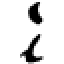
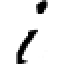
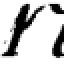
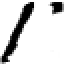
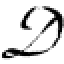
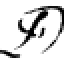
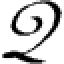
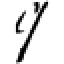
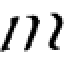
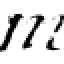
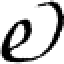
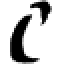
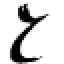
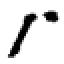
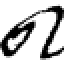
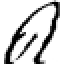
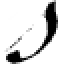
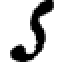
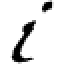
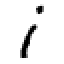
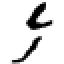
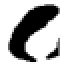
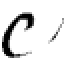
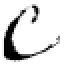
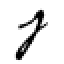
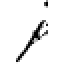
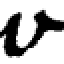
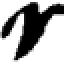
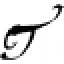
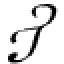
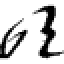
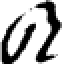
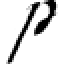
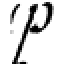
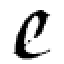
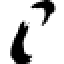
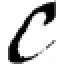
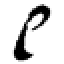
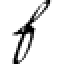
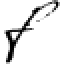
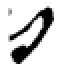
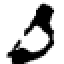
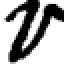
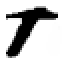
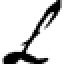
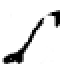
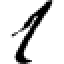
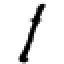
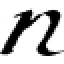
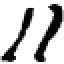
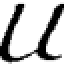
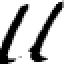
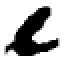
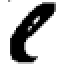
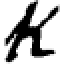
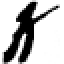
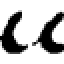
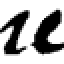
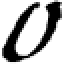
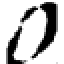
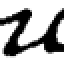
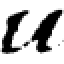
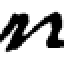
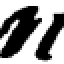
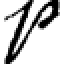
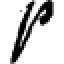
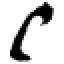
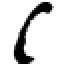
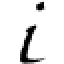
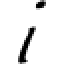
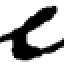
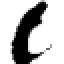
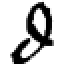
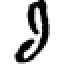
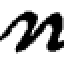
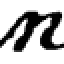
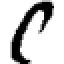
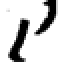
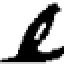
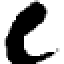
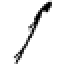
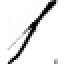
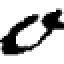
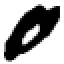
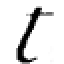
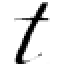
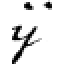
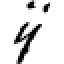
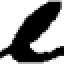
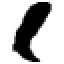
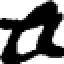
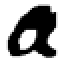
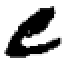
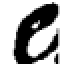
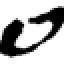
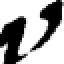
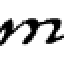
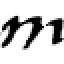
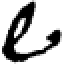
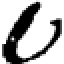
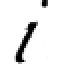
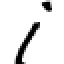
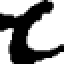
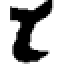
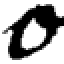
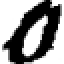
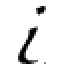
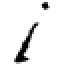
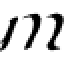
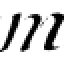
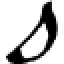
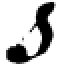
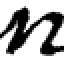
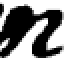
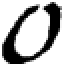
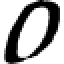
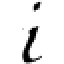
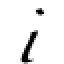
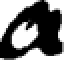
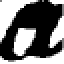
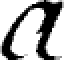
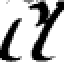
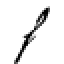
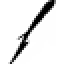
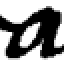
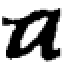
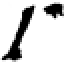
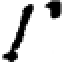

In [9]:
def _image_vers_base64(chemin, taille=64):
    img = Image.open(chemin).convert("L").resize((taille, taille), Image.NEAREST)
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

def _img_html(chemin, taille=64):
    b64 = _image_vers_base64(chemin, taille)
    return f'<img src="data:image/png;base64,{b64}" width="{taille}" height="{taille}" style="image-rendering:pixelated; border:1px solid #ccc;">'

def tableau_visuel(df, taille_image=64):
    lignes_html = []
    for _, row in df.iterrows():
        lignes_html.append(f"""
        <tr>
            <td style="padding:6px; text-align:center;">{row['mot']}</td>
            <td style="padding:6px; text-align:center; font-weight:bold;">{row['lettre']}</td>
            <td style="padding:6px; text-align:center;">{_img_html(row['chemin_1007'], taille_image)}</td>
            <td style="padding:6px; text-align:center;">{_img_html(row['chemin_1054'], taille_image)}</td>
            <td style="padding:6px; text-align:center;">{row['score']:.4f}</td>
            <td style="padding:6px; text-align:center; color:#888;">{row['score_sans_centrage']:.4f}</td>
        </tr>""")
    html = f"""
    <table style="border-collapse:collapse; width:100%;">
        <tr style="background:#f0f0f0; font-weight:bold;">
            <td style="padding:6px; text-align:center;">Mot</td>
            <td style="padding:6px; text-align:center;">Lettre</td>
            <td style="padding:6px; text-align:center;">Image 1007</td>
            <td style="padding:6px; text-align:center;">Image 1054</td>
            <td style="padding:6px; text-align:center;">Similarité (centrée)</td>
            <td style="padding:6px; text-align:center;">Similarité (brute)</td>
        </tr>
        {"".join(lignes_html)}
    </table>
    """
    return HTML(html)

# Affiche le tableau visuel complet (les 64 paires), triées des plus différentes aux plus semblables
display(tableau_visuel(df))


## 7. Export des résultats

- `resultats_similarite.csv` : tableau (mot, lettre, chemins des fichiers, scores) — sans les images, pour analyse externe (Excel, Python, etc.)
- `tableau_visuel.html` : le tableau avec les images intégrées, consultable dans un navigateur sans exécuter le notebook.

In [10]:
CSV_PATH = "/content/resultats_similarite.csv"
HTML_PATH = "/content/tableau_visuel.html"

df_affichage.to_csv(CSV_PATH, index=False, encoding="utf-8-sig")

with open(HTML_PATH, "w", encoding="utf-8") as f:
    f.write(tableau_visuel(df).data)

print("Fichiers écrits :")
print(" -", CSV_PATH)
print(" -", HTML_PATH)

try:
    from google.colab import files
    files.download(CSV_PATH)
    files.download(HTML_PATH)
except ImportError:
    pass


Fichiers écrits :
 - /content/resultats_similarite.csv
 - /content/tableau_visuel.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Visualisations complémentaires

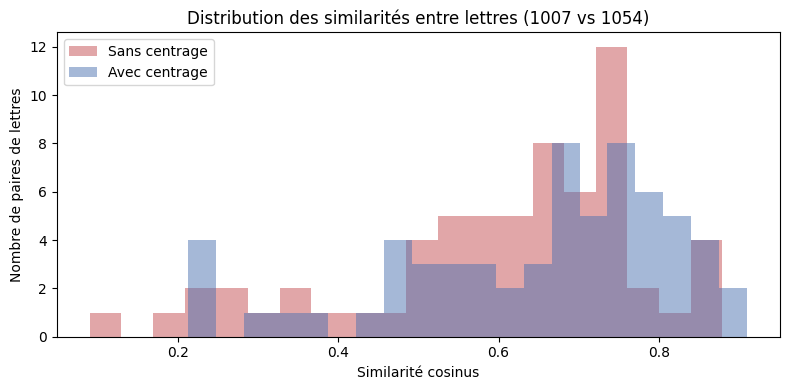

In [11]:
# Distribution des scores de similarité, avec et sans centrage
plt.figure(figsize=(8, 4))
plt.hist(df["score_sans_centrage"].dropna(), bins=20, alpha=0.5, label="Sans centrage", color="#C44E52")
plt.hist(df["score"].dropna(), bins=20, alpha=0.5, label="Avec centrage", color="#4C72B0")
plt.xlabel("Similarité cosinus")
plt.ylabel("Nombre de paires de lettres")
plt.title("Distribution des similarités entre lettres (1007 vs 1054)")
plt.legend()
plt.tight_layout()
plt.show()


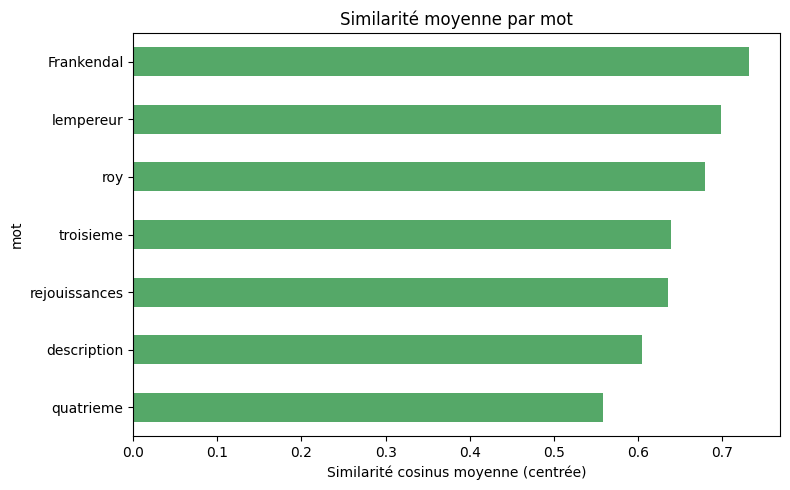

In [12]:
# Similarité moyenne par mot (avec centrage)
moyenne_par_mot = df.groupby("mot")["score"].mean().sort_values()

plt.figure(figsize=(8, 5))
moyenne_par_mot.plot(kind="barh", color="#55A868")
plt.xlabel("Similarité cosinus moyenne (centrée)")
plt.title("Similarité moyenne par mot")
plt.tight_layout()
plt.show()


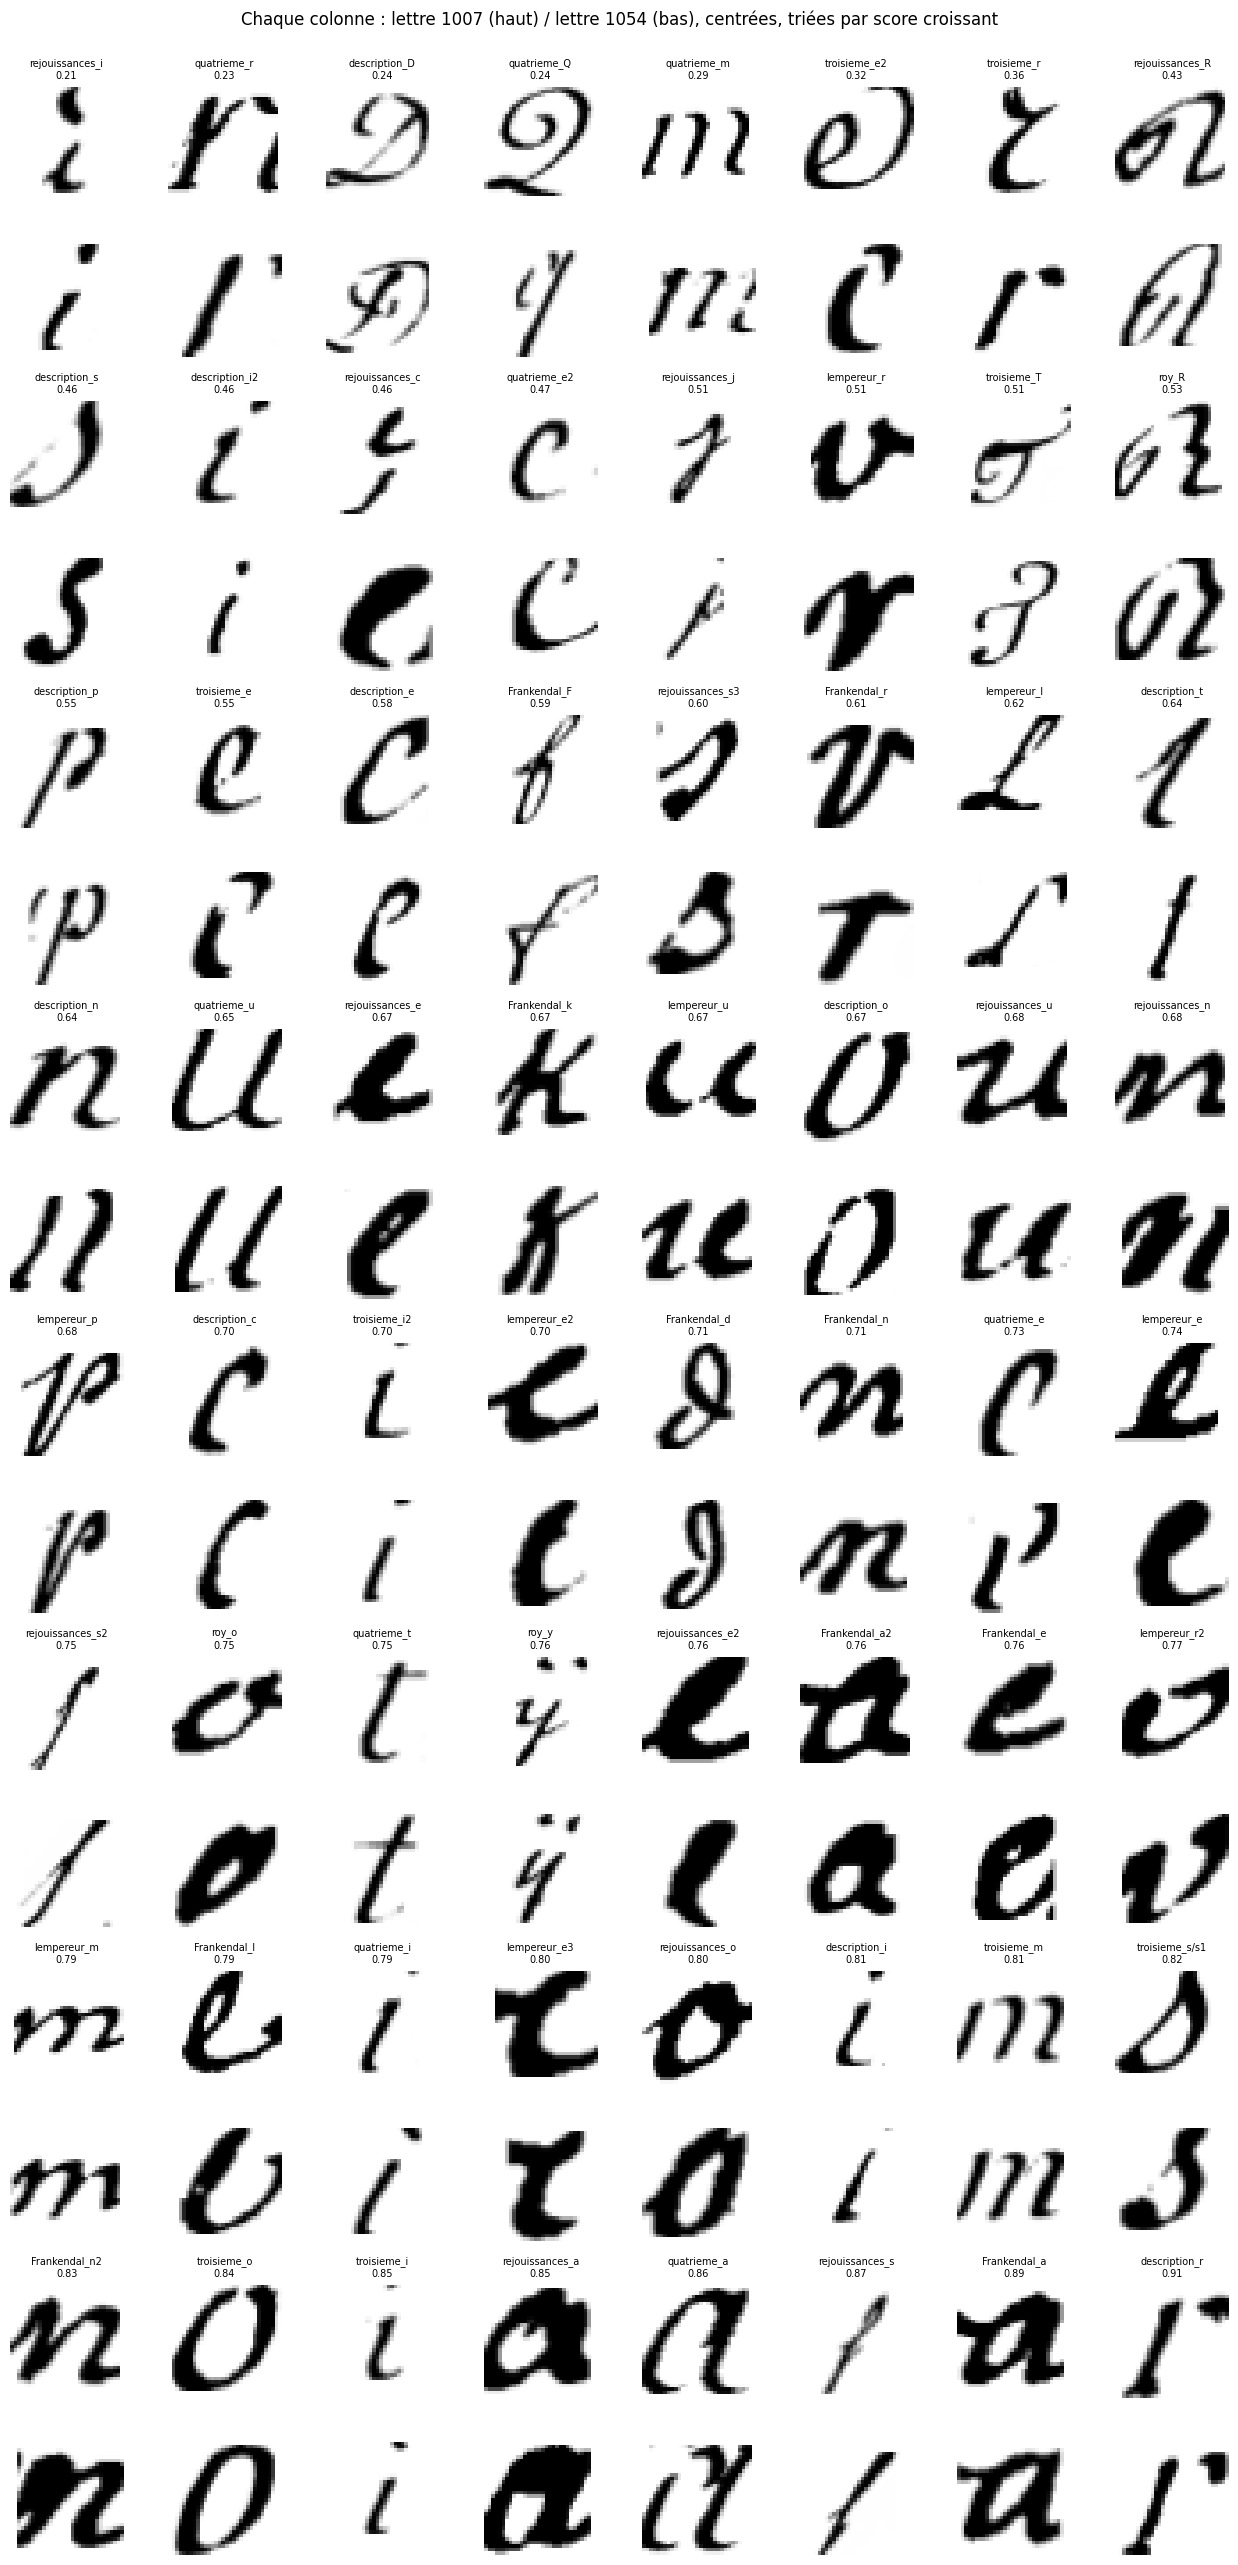

In [13]:
# Grille visuelle de toutes les paires - lettres CENTRÉES (celles utilisées pour le score), triées par score
n = len(df)
n_cols = 8
n_rows = int(np.ceil(n / n_cols)) * 2  # 2 lignes de miniatures (1007 puis 1054) par bloc de lignes

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.6, n_rows * 1.6))
axes = axes.reshape(n_rows, n_cols)

for idx, row in df.reset_index(drop=True).iterrows():
    bloc = idx // n_cols
    col = idx % n_cols
    ax_a = axes[bloc * 2, col]
    ax_b = axes[bloc * 2 + 1, col]

    img_a = pour_affichage(centrer_lettre(charger_image_inversee(row["chemin_1007"])))
    img_b = pour_affichage(centrer_lettre(charger_image_inversee(row["chemin_1054"])))

    ax_a.imshow(img_a, cmap="gray", vmin=0, vmax=255)
    ax_a.set_title(f"{row['mot']}_{row['lettre']}\n{row['score']:.2f}", fontsize=7)
    ax_a.axis("off")

    ax_b.imshow(img_b, cmap="gray", vmin=0, vmax=255)
    ax_b.axis("off")

# masque les cases vides restantes
for ax in axes.flatten():
    if not ax.has_data():
        ax.axis("off")

plt.suptitle("Chaque colonne : lettre 1007 (haut) / lettre 1054 (bas), centrées, triées par score croissant", y=1.0)
plt.tight_layout()
plt.show()


## 9. Heatmap de la similarité cosinus

En plus du score entre chaque lettre et **sa** correspondante, on peut regarder la similarité cosinus entre **toutes** les lettres du manuscrit 1007 et **toutes** les lettres du manuscrit 1054 (matrice 64×64), sous forme de heatmap.

Cela sert à vérifier que chaque lettre 1007 est bien plus proche de sa correspondante en 1054 (la diagonale, encadrée en rouge) que des autres lettres — et à repérer d'éventuelles confusions entre lettres qui se ressemblent visuellement (ex: `e`/`c`, `n`/`u`).

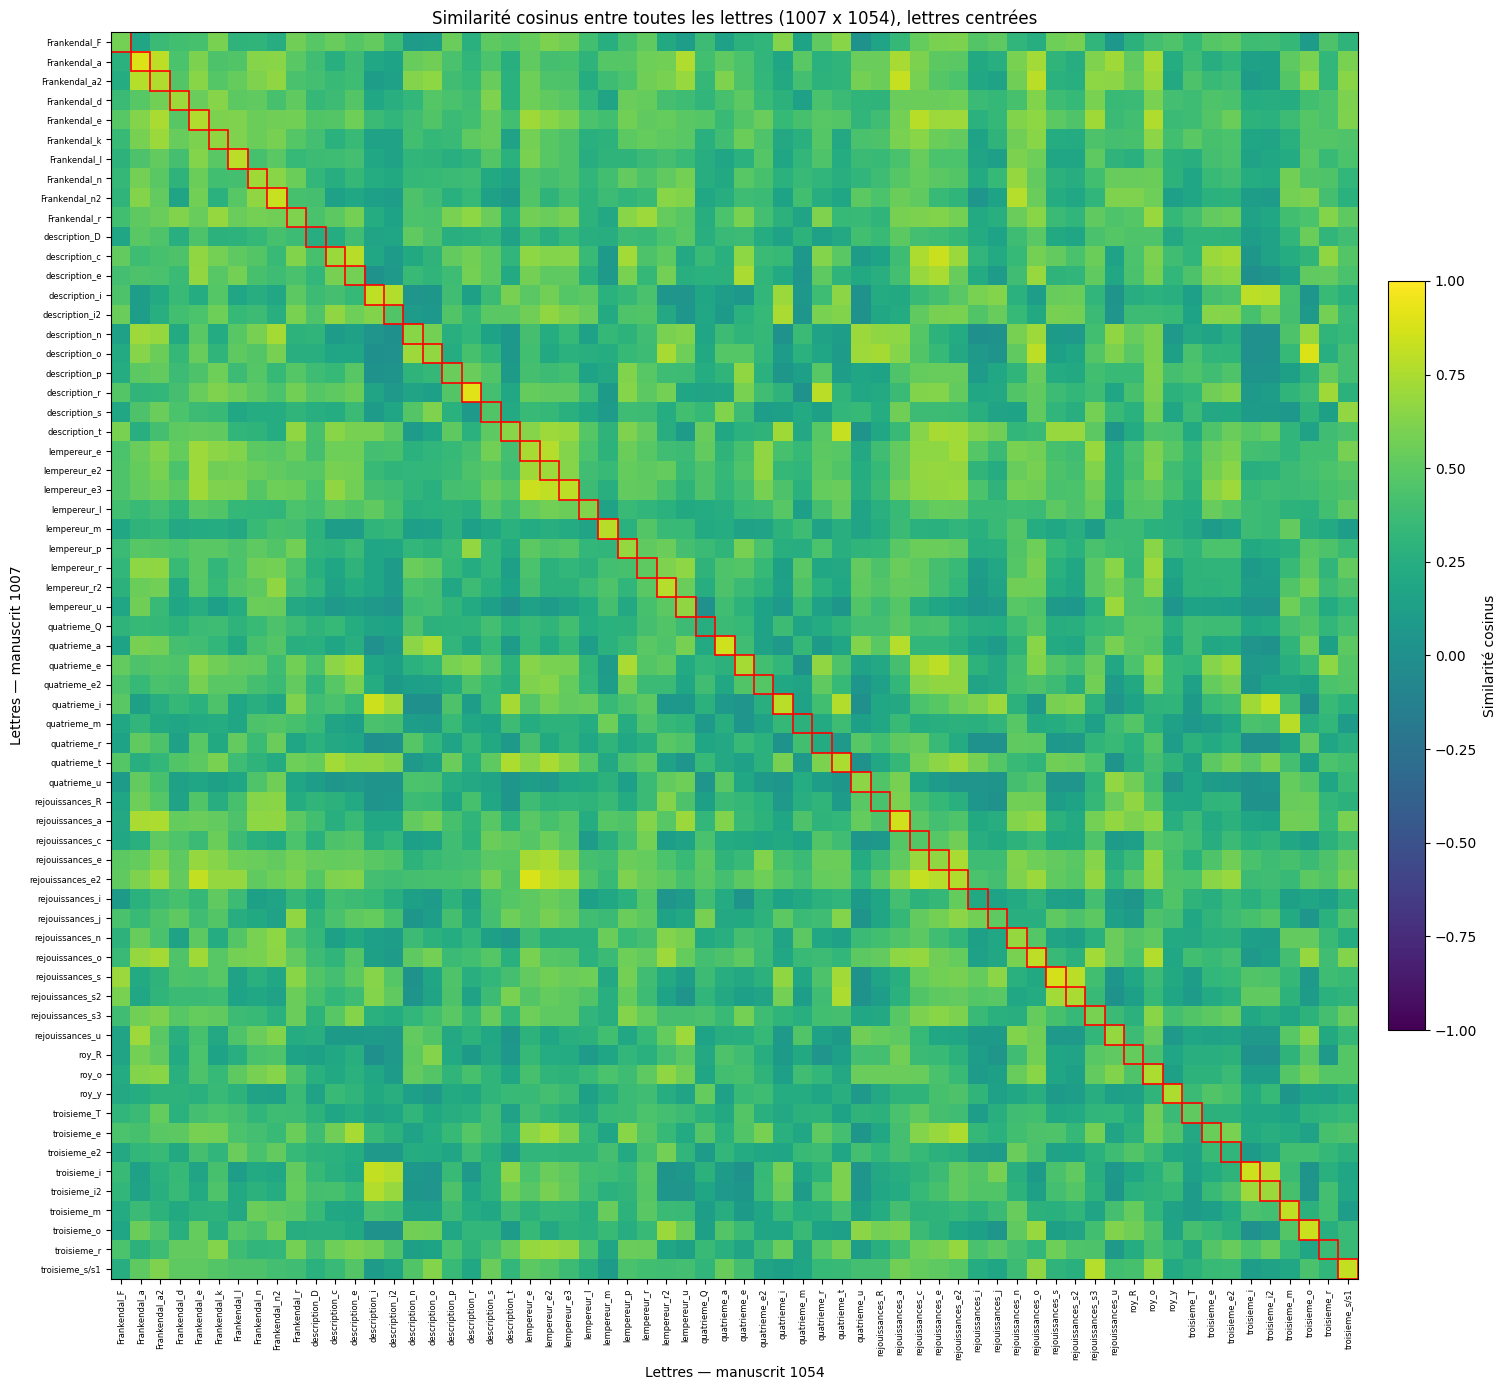

In [14]:
# Matrice complète des similarités cosinus (toutes lettres 1007 x toutes lettres 1054), lettres centrées
labels = [f"{p['mot']}_{p['lettre']}" for p in pairs]
matrice_similarite = normaliser_lignes(features_1007_centre) @ normaliser_lignes(features_1054_centre).T

fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(matrice_similarite, cmap="viridis", vmin=-1, vmax=1)

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=6)
ax.set_yticklabels(labels, fontsize=6)
ax.set_xlabel("Lettres — manuscrit 1054")
ax.set_ylabel("Lettres — manuscrit 1007")
ax.set_title("Similarité cosinus entre toutes les lettres (1007 x 1054), lettres centrées")

# encadre la diagonale (paires réellement appariées mot/lettre) pour repérage visuel
for i in range(len(labels)):
    ax.add_patch(plt.Rectangle((i - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="red", linewidth=1.2))

plt.colorbar(im, ax=ax, label="Similarité cosinus", fraction=0.025, pad=0.02)
plt.tight_layout()
plt.show()


## 10. Le copiste est-il le même ?

Il n'existe pas de seuil universel de similarité cosinus qui "prouve" qu'un même copiste a écrit deux manuscrits — ce chiffre dépend entièrement de la variabilité naturelle d'une main. La bonne approche est donc **comparative** plutôt qu'un seuil absolu : on construit une référence de variabilité *intra-manuscrit* (même copiste par hypothèse), et on regarde si la similarité *inter-manuscrits* s'en écarte ou non.

**Référence intra-manuscrit** : dans chaque manuscrit, une même lettre revient plusieurs fois dans des mots différents (ex: le `e` de `description`, `Frankendal`, `lempereur`...). En comparant ces occurrences entre elles, on obtient une distribution "même copiste, même lettre, contexte différent" — la variabilité qu'on peut attendre d'une seule main.

On compare ensuite cette référence à la distribution des scores inter-manuscrits (vos paires 1007↔1054), avec un test de Mann-Whitney (test non paramétrique, adapté à des échantillons de cette taille sans supposer une distribution normale).

Intra-1007      (n=124) : moyenne=0.563, médiane=0.585
Intra-1054      (n=124) : moyenne=0.627, médiane=0.659
Inter 1007↔1054 (n=64) : moyenne=0.646, médiane=0.684

Test de Mann-Whitney (inter vs intra) : p-valeur = 0.0206
-> La similarité inter-manuscrits est significativement PLUS FORTE que la variabilité
   intra-manuscrit : à interpréter avec prudence (voir note ci-dessous).


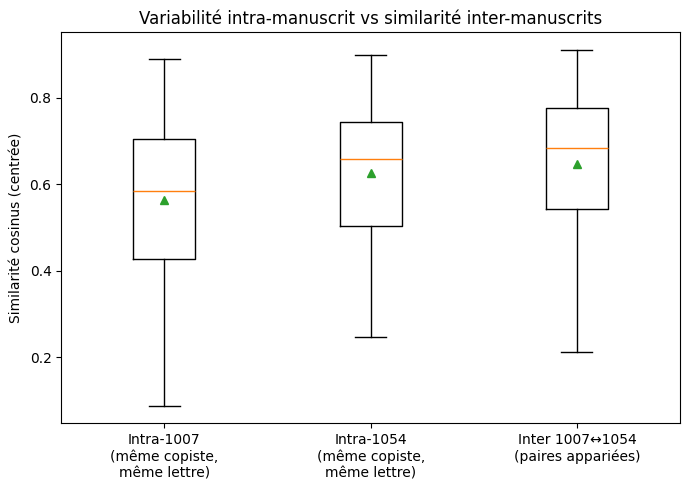

In [15]:
from itertools import combinations
from scipy import stats as scipy_stats

def vecteur_lettre_centre(chemin):
    return centrer_lettre(charger_image_inversee(chemin)).flatten()

def similarites_intra_manuscrit(manuscrit):
    """Similarité cosinus entre toutes les occurrences d'une même lettre (indépendamment du mot),
    à l'intérieur d'un seul manuscrit -> sert de référence 'même copiste, même lettre'."""
    groupes = defaultdict(list)
    for mot, lettres in data[manuscrit].items():
        for lettre, chemin in lettres.items():
            base, _ = _split_label(lettre)
            groupes[base].append(chemin)

    scores = []
    for base, chemins in groupes.items():
        if len(chemins) < 2:
            continue  # lettre présente une seule fois dans ce manuscrit : pas de comparaison possible
        vecteurs = [vecteur_lettre_centre(c) for c in chemins]
        for i, j in combinations(range(len(vecteurs)), 2):
            n1, n2 = np.linalg.norm(vecteurs[i]), np.linalg.norm(vecteurs[j])
            if n1 == 0 or n2 == 0:
                continue
            scores.append(float(np.dot(vecteurs[i], vecteurs[j]) / (n1 * n2)))
    return scores

scores_intra_1007 = similarites_intra_manuscrit("1007")
scores_intra_1054 = similarites_intra_manuscrit("1054")
scores_intra_tout = scores_intra_1007 + scores_intra_1054
scores_inter = [p["score"] for p in pairs]

print(f"Intra-1007      (n={len(scores_intra_1007)}) : moyenne={np.mean(scores_intra_1007):.3f}, médiane={np.median(scores_intra_1007):.3f}")
print(f"Intra-1054      (n={len(scores_intra_1054)}) : moyenne={np.mean(scores_intra_1054):.3f}, médiane={np.median(scores_intra_1054):.3f}")
print(f"Inter 1007↔1054 (n={len(scores_inter)}) : moyenne={np.mean(scores_inter):.3f}, médiane={np.median(scores_inter):.3f}")

u_stat, p_value = scipy_stats.mannwhitneyu(scores_inter, scores_intra_tout, alternative="two-sided")
print(f"\nTest de Mann-Whitney (inter vs intra) : p-valeur = {p_value:.4f}")
if p_value > 0.05:
    print("-> Pas de différence statistiquement significative : la similarité inter-manuscrits est")
    print("   compatible avec la variabilité naturelle d'un même copiste sur ce jeu de données.")
elif np.mean(scores_inter) < np.mean(scores_intra_tout):
    print("-> La similarité inter-manuscrits est significativement PLUS FAIBLE que la variabilité")
    print("   intra-manuscrit : indice en faveur de DEUX copistes différents.")
else:
    print("-> La similarité inter-manuscrits est significativement PLUS FORTE que la variabilité")
    print("   intra-manuscrit : à interpréter avec prudence (voir note ci-dessous).")

fig, ax = plt.subplots(figsize=(7, 5))
ax.boxplot(
    [scores_intra_1007, scores_intra_1054, scores_inter],
    tick_labels=["Intra-1007\n(même copiste,\nmême lettre)", "Intra-1054\n(même copiste,\nmême lettre)", "Inter 1007↔1054\n(paires appariées)"],
    showmeans=True,
)
ax.set_ylabel("Similarité cosinus (centrée)")
ax.set_title("Variabilité intra-manuscrit vs similarité inter-manuscrits")
plt.tight_layout()
plt.show()


**Deuxième figure : projection PCA.**

On projette toutes les lettres centrées des deux manuscrits (128 images) dans un plan 2D qui capture le plus de variabilité de forme possible. Un trait fin relie chaque paire appariée. Si les points des deux manuscrits s'entremêlent (pas de séparation nette par couleur), c'est un indice que la forme des lettres varie plus selon la lettre elle-même que selon le manuscrit — cohérent avec un même style d'écriture. Si les deux manuscrits forment deux nuages nettement séparés, c'est un indice de styles différents.

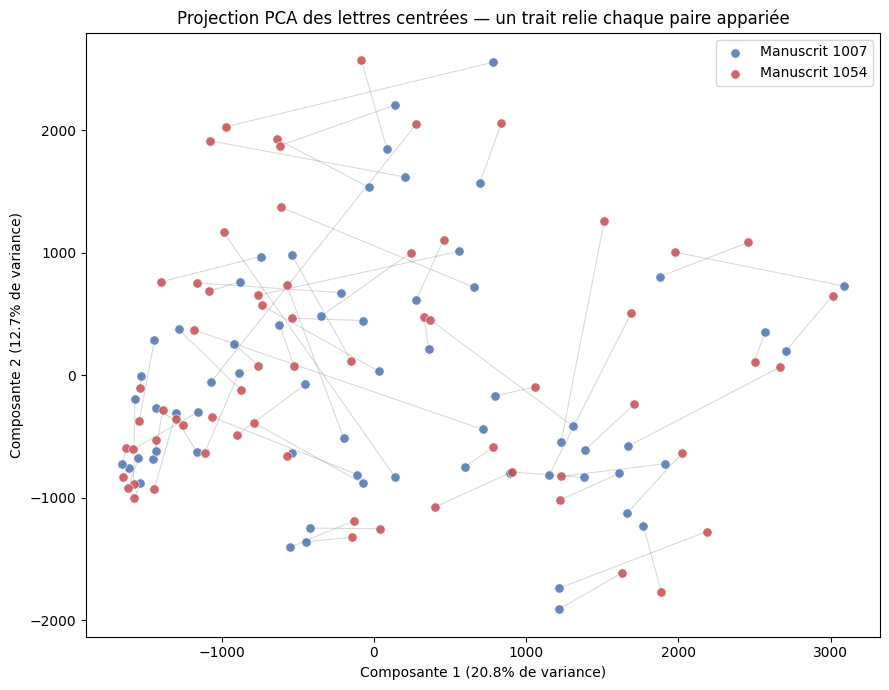

In [16]:
from sklearn.decomposition import PCA

toutes_chemins, toutes_manuscrits = [], []
for manuscrit in ["1007", "1054"]:
    for mot, lettres in data[manuscrit].items():
        for lettre, chemin in lettres.items():
            toutes_chemins.append(chemin)
            toutes_manuscrits.append(manuscrit)

toutes_features = construire_matrice(toutes_chemins, centrer=True)
pca = PCA(n_components=2)
coords = pca.fit_transform(toutes_features)

fig, ax = plt.subplots(figsize=(9, 7))

chemin_vers_idx = {c: i for i, c in enumerate(toutes_chemins)}
for p in pairs:
    i, j = chemin_vers_idx[p["chemin_1007"]], chemin_vers_idx[p["chemin_1054"]]
    ax.plot([coords[i, 0], coords[j, 0]], [coords[i, 1], coords[j, 1]],
            color="gray", alpha=0.3, linewidth=0.8, zorder=0)

for manuscrit, couleur in [("1007", "#4C72B0"), ("1054", "#C44E52")]:
    mask = np.array(toutes_manuscrits) == manuscrit
    ax.scatter(coords[mask, 0], coords[mask, 1], label=f"Manuscrit {manuscrit}",
               alpha=0.85, s=45, color=couleur, edgecolor="white", linewidth=0.5)

ax.set_xlabel(f"Composante 1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
ax.set_ylabel(f"Composante 2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
ax.set_title("Projection PCA des lettres centrées — un trait relie chaque paire appariée")
ax.legend()
plt.tight_layout()
plt.show()


**Limites à garder en tête pour cette section :**

- L'hypothèse "un manuscrit = un seul copiste" n'est pas vérifiée ici, elle est supposée pour construire la référence — si un manuscrit a en réalité plusieurs mains, la variabilité intra-manuscrit sera surestimée.
- L'échantillon reste modeste (7 mots, 64 paires) : le test statistique a une puissance limitée, un résultat non significatif ne veut pas dire "même copiste prouvé", seulement "pas de preuve du contraire sur ce jeu de données".
- La similarité cosinus sur pixels bruts est une mesure grossière de la forme (sensible à l'épaisseur du trait, au seuillage, à la résolution). Une étude paléographique publiable s'appuierait normalement sur des critères complémentaires (ductus, proportions, angle d'inclinaison, liaisons entre lettres) en plus de ce type de mesure globale.


## Notes

- Le centrage annule les décalages de position, mais pas les différences d'échelle ou de forme réelle du tracé : un score qui baisse après centrage indique en général une vraie différence de forme entre les deux lettres (et non un simple problème d'alignement), tandis qu'un score qui augmente indique que l'essentiel de l'écart initial venait du cadrage.
- Une incohérence de nommage a été détectée automatiquement dans le jeu de données fourni (`troisieme_s` en 1007 vs `troisieme_s1` en 1054) : le notebook l'apparie quand même via une correspondance approchée, et l'affiche dans les avertissements de la section 3. Vérifiez cet avertissement si vous ajoutez de nouvelles images.


--- Analyse des seuils --- 
Seuil optimal (maximise le F1-score) : 0.7518
  -> Précision à ce seuil : 0.3485
  -> Rappel à ce seuil : 0.3594
  -> F1-score maximal : 0.3538


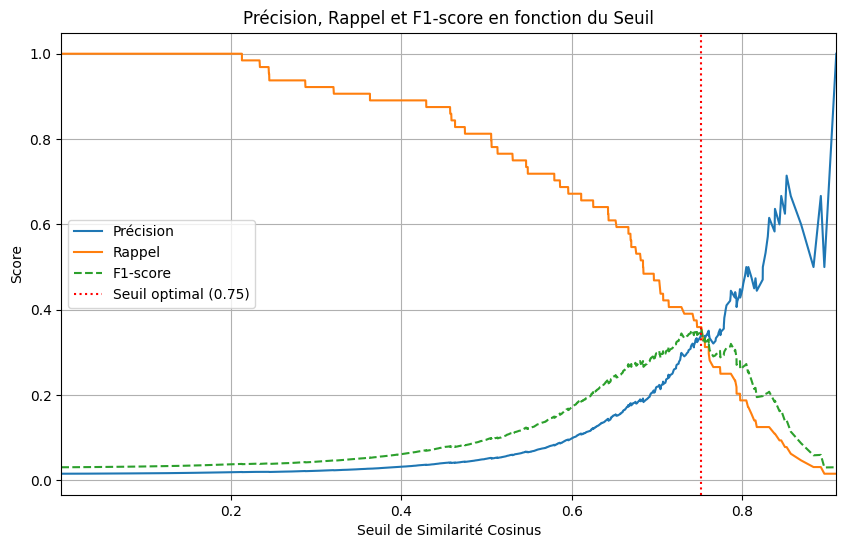


Interprétation : Le graphique montre comment la précision et le rappel évoluent lorsque vous changez le seuil de similarité. Le F1-score, lui, essaie de trouver le meilleur compromis entre les deux. Le pointillé rouge indique le seuil qui maximise ce F1-score. Si votre objectif est de privilégier la précision (peu de faux positifs) ou le rappel (ne pas rater de vrais positifs), vous pouvez ajuster le seuil en conséquence en vous aidant de cette courbe.


In [17]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Re-créer y_true et y_scores, car ils étaient dans une cellule supprimée
# Assurez-vous que 'matrice_similarite' et 'labels' sont disponibles depuis les cellules précédentes
n_pairs = len(labels)

y_true = np.zeros((n_pairs, n_pairs))
np.fill_diagonal(y_true, 1) # Set diagonal to 1 for true matches
y_true = y_true.flatten()

y_scores = matrice_similarite.flatten()

# Calculer la précision, le rappel et les seuils pour différentes valeurs
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# Calculer le F1-score pour chaque seuil
f1_scores = []
for p, r in zip(precision, recall):
    if (p + r) == 0:
        f1_scores.append(0.0)
    else:
        f1_scores.append(2 * (p * r) / (p + r))

f1_scores = np.array(f1_scores)

# Trouver le seuil qui maximise le F1-score
optimal_f1_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_f1_idx]
optimal_precision = precision[optimal_f1_idx]
optimal_recall = recall[optimal_f1_idx]

print(f"--- Analyse des seuils --- ")
print(f"Seuil optimal (maximise le F1-score) : {optimal_threshold:.4f}")
print(f"  -> Précision à ce seuil : {optimal_precision:.4f}")
print(f"  -> Rappel à ce seuil : {optimal_recall:.4f}")
print(f"  -> F1-score maximal : {f1_scores[optimal_f1_idx]:.4f}")

# Tracer les courbes de précision, rappel et F1-score en fonction des seuils
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Précision', linestyle='-')
plt.plot(thresholds, recall[:-1], label='Rappel', linestyle='-')
plt.plot(thresholds, f1_scores[:-1], label='F1-score', linestyle='--')
plt.axvline(x=optimal_threshold, color='red', linestyle=':', label=f'Seuil optimal ({optimal_threshold:.2f})')

plt.xlabel('Seuil de Similarité Cosinus')
plt.ylabel('Score')
plt.title('Précision, Rappel et F1-score en fonction du Seuil')
plt.legend()
plt.grid(True)
plt.xlim([y_scores.min(), y_scores.max()]) # Limiter l'axe x aux valeurs de score réelles
plt.show()

print("\nInterprétation : Le graphique montre comment la précision et le rappel évoluent lorsque vous changez le seuil de similarité. Le F1-score, lui, essaie de trouver le meilleur compromis entre les deux. Le pointillé rouge indique le seuil qui maximise ce F1-score. Si votre objectif est de privilégier la précision (peu de faux positifs) ou le rappel (ne pas rater de vrais positifs), vous pouvez ajuster le seuil en conséquence en vous aidant de cette courbe.")